In [104]:
import numpy as np
import matplotlib.pyplot as plt

# Data generation
np.random.seed(0)
[n,m] = [3,4]
W = np.random.rand(m, n)
# worse conditionning makes mSOM and Gradient descent more visibly distinct
W[:,2] = 0.1*W[:,2]+0.45*W[:,0] + 0.45*W[:,1]  # col 3 is col 1 + col 2
xmin = np.random.rand(n)
y = W@xmin

def maj(xk,x,W,y, case='MU'):
    """ Majorant function for the Frobenius NNLS loss at xk, obtained with the MU algorithm.
    returns MU, mSOM and GD majorants
    """
    Wxk = W@xk
    WtW = W.T@W
    Wty = W.T@y
    if case=='MU':
        Precond = WtW@xk/xk
    elif case=='mSOM':
        Precond = WtW@np.ones(n)
    elif case=='GD':
        Precond = np.linalg.norm(WtW, 2)*np.ones(n)
    return np.sum((Wxk - y)**2) + (x - xk).T@(2*WtW@xk - 2*Wty) + np.sum(Precond * (x - xk)**2),


def loss_compute(x0, v, t, W, y):
    """ Compute the Frobenius NNLS loss at x0 + t*v, restricted to the nonnegative orthant.
    """
    steps = [v*t[i] for i in range(len(t))] 
    xs = [x0 + steps[i] for i in range(len(t))]
    return [ [np.linalg.norm(y - W@xs[i])**2 for i in range(len(t)) if np.min(xs[i])>=0],
             [maj(x0, xs[i], W, y, case="MU") for i in range(len(t)) if np.min(xs[i])>=0],
             [maj(x0, xs[i], W, y, case="mSOM") for i in range(len(t)) if np.min(xs[i])>=0],
             [maj(x0, xs[i], W, y, case="GD") for i in range(len(t)) if np.min(xs[i])>=0],
             ], [t[i] for i in range(len(t)) if np.min(xs[i])>=0]

# We plot the Frobenius NNLS loss on three 1d slices of the 3d cost
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([0, 0, 1])

x0 = xmin + np.array([0.2, 0.5, 0.1])  # we plot the loss centered on this point

t = np.linspace(-1, 0.5, 100)
[L1, Lmu1, LmSOM1, LGD1], ts1 = loss_compute(x0, v1, t, W, y)
[L2, Lmu2, LmSOM2, LGD2], ts2 = loss_compute(x0, v2, t, W, y)
[L3, Lmu3, LmSOM3, LGD3], ts3 = loss_compute(x0, v3, t, W, y)

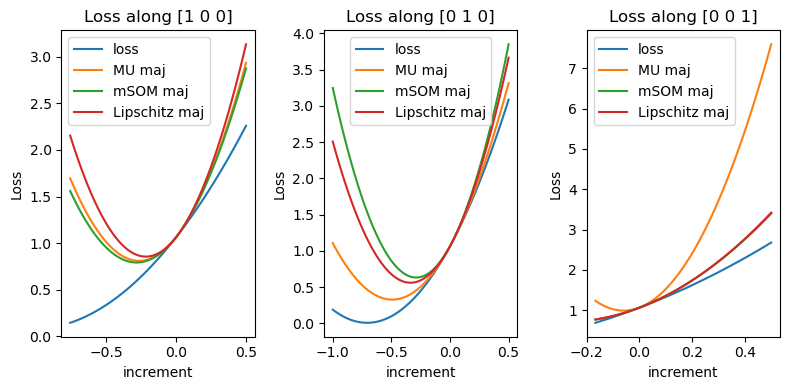

In [105]:
# Plot the three curves in the same figure with subplots
fig, ax = plt.subplots(1,3, figsize=(8, 4))
ax[0].plot(ts1, L1, label='loss')
ax[0].plot(ts1, Lmu1, label='MU maj')
ax[0].plot(ts1, LmSOM1, label='mSOM maj')
ax[0].plot(ts1, LGD1, label='Lipschitz maj')
ax[0].set_title(f'Loss along {v1}')
ax[0].set_xlabel('increment')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(ts2, L2, label='loss')
ax[1].plot(ts2, Lmu2, label='MU maj')
ax[1].plot(ts2, LmSOM2, label='mSOM maj')
ax[1].plot(ts2, LGD2, label='Lipschitz maj')
ax[1].set_title(f'Loss along {v2}')
ax[1].set_xlabel('increment')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[2].plot(ts3, L3, label='loss')
ax[2].plot(ts3, Lmu3, label='MU maj')
ax[2].plot(ts3, LmSOM3, label='mSOM maj')
ax[2].plot(ts3, LGD3, label='Lipschitz maj')
ax[2].set_title(f'Loss along {v3}')
ax[2].set_xlabel('increment')
ax[2].set_ylabel('Loss')
ax[2].legend()
plt.tight_layout()
plt.savefig('mSOM_majorants.png', dpi=300)
plt.show()

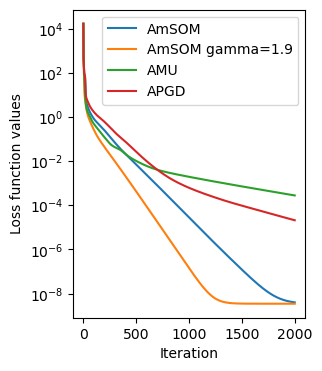

In [110]:

import numpy as np
import matplotlib.pyplot as plt


def mSOM_update(HtH, YH, W, precond, gamma=1.9, epsilon=0):
    ''' Computes the mSOM update rules for the NNLS problem min_{W\geq 0} ||Y - WH^T||_F^2
    '''
    W = np.maximum(W - gamma * precond * (W @ HtH - YH), epsilon) 
    return W

def MU_update(HtH, YH, W, epsilon=0):
    ''' Computes the mSOM update rules for the NNLS problem min_{W\geq 0} ||Y - WH^T||_F^2
    '''
    W = np.maximum(W * (YH / (W @ HtH)), epsilon) 
    return W

def AmSOM(Y, Winit, Hinit, method="mSOM", niter=100, gamma=1.9, epsilon=0):
    ''' Alternating mSOM for the NNLS problem min_{W,H\geq 0} ||Y - WH^T||_F^2
    Using 10 inner iterations for the mSOM updates of W and H.
    '''
    W = np.copy(Winit)
    H = np.copy(Hinit)
    loss = [1/2*np.linalg.norm(Y - W @ H.T, 'fro')**2]
    for it in range(niter):
        HtH = H.T @ H
        if method=="GD":
            step = 1/np.linalg.norm(HtH,2)
        YH = Y @ H
        precond_W = 1/np.sum(HtH, axis=1)  # makes use of broadcasting
        for _i in range(10):
            if method == "MU":
                W = MU_update(HtH, YH, W, epsilon=epsilon)
            elif method=="mSOM":
                W = mSOM_update(HtH, YH, W, precond_W, gamma=gamma, epsilon=epsilon)
            elif method=="GD":
                W = np.maximum(W - gamma*step*(W@HtH - YH), epsilon)

        WtW = W.T @ W
        if method=="GD":
            step = 1/np.linalg.norm(WtW,2)
        YW = Y.T @ W
        precond_H = 1/np.sum(WtW, axis=1)  # makes use of broadcasting
        for _i in range(10):
            if method == "MU":
                H = MU_update(WtW, YW, H, epsilon=epsilon)
            elif method=="mSOM":
                H = mSOM_update(WtW, YW, H, precond_H, gamma=gamma, epsilon=epsilon)
            elif method=="GD":
                H = np.maximum(H - gamma*step*(H@WtW - YW), epsilon)

        loss.append(1/2*np.linalg.norm(Y - W @ H.T, 'fro')**2)
    return W, H, loss

# Exemple usage on a toy dataset
np.random.seed(27)
n, m, r = 100, 80, 5
niter = 2000
Wtrue = np.random.rand(n, r)
Htrue = np.abs(np.random.randn(m, r))
Y = Wtrue @ Htrue.T + 1e-6 * np.random.randn(n, m)

Winit = np.abs(np.random.randn(n, r))
Hinit = np.abs(np.random.randn(m, r))

W, H, err_msom = AmSOM(Y, Winit, Hinit, method="mSOM", niter=niter, gamma=1, epsilon=0)
Wg, Hg, err_msomg = AmSOM(Y, Winit, Hinit, method="mSOM", niter=niter, gamma=1.9, epsilon=0)
W_mu, H_mu, err_mu = AmSOM(Y, Winit, Hinit, method="MU", niter=niter, gamma=1, epsilon=0)
W_gd, H_gd, err_gd = AmSOM(Y, Winit, Hinit, method="GD", niter=niter, gamma=1, epsilon=0)
W_gdg, H_gdg, err_gdg = AmSOM(Y, Winit, Hinit, method="GD", niter=niter, gamma=1.9, epsilon=0)


# comparing the convergence plot
plt.figure(figsize=(3,4))
plt.semilogy(err_msom, label='AmSOM')
plt.semilogy(err_msomg, label='AmSOM gamma=1.9')
plt.semilogy(err_mu, label='AMU')
plt.semilogy(err_gd, label='APGD')
#plt.semilogy(err_gdg, label='GD gamma=1.9')
plt.xlabel('Iteration')
plt.ylabel('Loss function values')
plt.legend()

plt.savefig('mSOM_convergence.png', dpi=300,  bbox_inches='tight', pad_inches=0.1)

plt.show()